# CLASP terms on DBAASP (`all_in`)

Filter `results/data/all_in/peptides_apex.csv` to DBAASP sequences, reuse the
stored APEX MIC for *S. aureus* ATCC 12600, and score the product-variant
MEROPS cleavage term Φ<sub>cleav</sub>.

- Descriptive statistics: **cleavage term** Φ<sub>cleav</sub> only
- Histogram of Φ<sub>cleav</sub>
- Scatter: log<sub>2</sub> MIC vs Φ<sub>cleav</sub>
- Overlaid histograms of the CLASP potential
  `log2_mic + λ · Φ_cleav` for λ ∈ {0.1, 0.5, 0.9}
- Literature stable/labile *S. aureus* protease controls on the DBAASP Φ distribution

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "src" / "pep_compass").is_dir()),
    cwd,
)
sys.path.insert(0, str(project_root / "src"))

ALL_IN_CSV = project_root / "results" / "data" / "all_in" / "peptides_apex.csv"
OUT_DIR = project_root / "results" / "clasp_dbaasp_inspection"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIC_COLUMN = "S. aureus ATCC 12600"
APEX_INDEX = 7          # same strain as MIC_COLUMN / MEROPS dataset 7
MEROPS_DATASETS = (7,)
VARIANT = "product"
LAMBDAS = (0.1, 0.5, 0.9)
DEVICE = "cpu"

print("project_root:", project_root)
print("all_in csv:", ALL_IN_CSV, "exists=", ALL_IN_CSV.exists())

project_root: C:\Users\Karol\Desktop\PepCompass\pep-compass
all_in csv: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\data\all_in\peptides_apex.csv exists= True


In [2]:
from pep_compass.local_enumeration.mutation.mutation_potentials import (
    CleavagePotential,
    load_protease_panel,
)

raw = pd.read_csv(ALL_IN_CSV, usecols=["sequence", "dataset", MIC_COLUMN])
dbaasp = (
    raw[raw["dataset"].str.contains("dbaasp", case=False, na=False)]
    .drop_duplicates(subset=["sequence"])
    .reset_index(drop=True)
)
dbaasp["length"] = dbaasp["sequence"].str.len()
dbaasp["mic_uM"] = dbaasp[MIC_COLUMN].astype(float)
dbaasp["log2_mic"] = np.log2(dbaasp["mic_uM"])

print(f"DBAASP peptides: {len(dbaasp)} (unique sequences)")
print(dbaasp["length"].describe().round(2))

DBAASP peptides: 3038 (unique sequences)
count    3038.00
mean       16.86
std         4.35
min        10.00
25%        13.00
50%        17.00
75%        20.00
max        25.00
Name: length, dtype: float64


In [3]:
panel = load_protease_panel(MEROPS_DATASETS, device=DEVICE)
cleavage = CleavagePotential(panel, variant=VARIANT, device=DEVICE)
phi = (
    cleavage.sequence_log_potential(dbaasp["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
)
dbaasp["cleavage"] = phi.astype(float)          # Φ_cleav (product)
# cleavage_term at the default λ=0.1 used in CLASP; proportional for other λ
dbaasp["cleavage_term"] = 0.1 * dbaasp["cleavage"]

for lam in LAMBDAS:
    dbaasp[f"potential_lam_{lam}"] = dbaasp["log2_mic"] + lam * dbaasp["cleavage"]

out_csv = OUT_DIR / "dbaasp_clasp_components.csv"
dbaasp.to_csv(out_csv, index=False)
print("wrote", out_csv)
dbaasp[["sequence", "log2_mic", "cleavage", "cleavage_term"]].head()

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\dbaasp_clasp_components.csv


,sequence,log2_mic,cleavage,cleavage_term
0,AAARLRLLLYLITRR,5.557998,-16.037914,-1.603791
1,AAHCIALRKGYK,6.501487,-17.312645,-1.731264
2,AAHCIQLGKR,7.060378,-17.435198,-1.743520
3,AAHCIVLHHN,7.113450,-17.782173,-1.778217
4,AAHCLAIGRK,6.888802,-17.386063,-1.738606


## Descriptive statistics — cleavage term Φ<sub>cleav</sub>

Median, all deciles (P10…P90), quartiles, mean, variance / std, IQR, range,
and skewness / kurtosis of the product-variant cleavage potential.

In [4]:
x = dbaasp["cleavage"].to_numpy()
deciles = {f"p{p}": float(np.percentile(x, p)) for p in range(10, 100, 10)}
stats = {
    "n": int(x.size),
    "mean": float(np.mean(x)),
    "median": float(np.median(x)),
    "std": float(np.std(x, ddof=1)),
    "variance": float(np.var(x, ddof=1)),
    "mad": float(np.median(np.abs(x - np.median(x)))),
    "iqr": float(np.percentile(x, 75) - np.percentile(x, 25)),
    "min": float(np.min(x)),
    "max": float(np.max(x)),
    "range": float(np.max(x) - np.min(x)),
    "q1": float(np.percentile(x, 25)),
    "q3": float(np.percentile(x, 75)),
    **deciles,
    "skewness": float(pd.Series(x).skew()),
    "kurtosis_excess": float(pd.Series(x).kurtosis()),
}
stats_df = pd.DataFrame({"metric": list(stats.keys()), "value": list(stats.values())})
stats_path = OUT_DIR / "cleavage_descriptive_stats.csv"
stats_df.to_csv(stats_path, index=False)
print(stats_df.to_string(index=False))
print("wrote", stats_path)

         metric       value
              n 3038.000000
           mean  -16.758027
         median  -16.695888
            std    0.699437
       variance    0.489212
            mad    0.470222
            iqr    0.959589
            min  -18.402334
            max  -11.528978
          range    6.873356
             q1  -17.257730
             q3  -16.298141
            p10  -17.694561
            p20  -17.398029
            p30  -17.143238
            p40  -16.909218
            p50  -16.695888
            p60  -16.518554
            p70  -16.380482
            p80  -16.203536
            p90  -15.991336
       skewness    0.440787
kurtosis_excess    2.236008
wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\cleavage_descriptive_stats.csv


## Histogram of Φ<sub>cleav</sub>

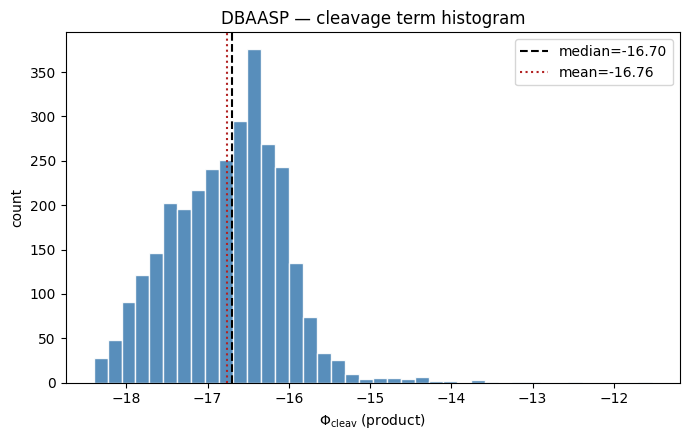

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(dbaasp["cleavage"], bins=40, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(stats["median"], color="black", ls="--", lw=1.5, label=f"median={stats['median']:.2f}")
ax.axvline(stats["mean"], color="firebrick", ls=":", lw=1.5, label=f"mean={stats['mean']:.2f}")
ax.set_xlabel(r"$\Phi_{\mathrm{cleav}}$ (product)")
ax.set_ylabel("count")
ax.set_title("DBAASP — cleavage term histogram")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "cleavage_histogram.png", dpi=150)
plt.show()

## Scatter: log<sub>2</sub> MIC vs cleavage term

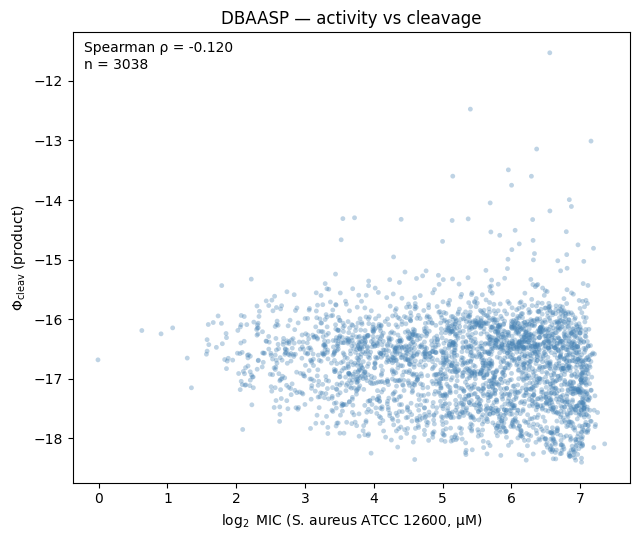

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(
    dbaasp["log2_mic"],
    dbaasp["cleavage"],
    s=12,
    alpha=0.35,
    c="steelblue",
    edgecolors="none",
)
ax.set_xlabel(r"$\log_2$ MIC (S. aureus ATCC 12600, µM)")
ax.set_ylabel(r"$\Phi_{\mathrm{cleav}}$ (product)")
ax.set_title("DBAASP — activity vs cleavage")
rho = dbaasp["log2_mic"].corr(dbaasp["cleavage"], method="spearman")
ax.text(
    0.02,
    0.98,
    f"Spearman ρ = {rho:.3f}\nn = {len(dbaasp)}",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "log2mic_vs_cleavage_scatter.png", dpi=150)
plt.show()

## Potential histograms for λ ∈ {0.1, 0.5, 0.9}

Potential minimized by the CLASP black box:
`potential(λ) = log2_mic + λ · Φ_cleav`.

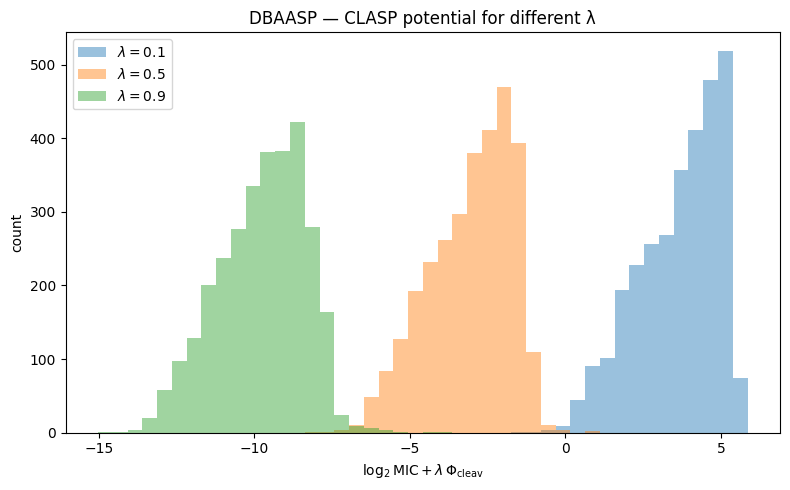

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {0.1: "#1f77b4", 0.5: "#ff7f0e", 0.9: "#2ca02c"}
# Shared bin edges so overlays are comparable
all_vals = np.concatenate([dbaasp[f"potential_lam_{lam}"].to_numpy() for lam in LAMBDAS])
bins = np.linspace(all_vals.min(), all_vals.max(), 45)
for lam in LAMBDAS:
    ax.hist(
        dbaasp[f"potential_lam_{lam}"],
        bins=bins,
        alpha=0.45,
        color=colors[lam],
        label=fr"$\lambda={lam}$",
        edgecolor="none",
    )
ax.set_xlabel(r"$\log_2\mathrm{MIC} + \lambda\,\Phi_{\mathrm{cleav}}$")
ax.set_ylabel("count")
ax.set_title("DBAASP — CLASP potential for different λ")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "potential_histograms_by_lambda.png", dpi=150)
plt.show()

In [8]:
print("Outputs in", OUT_DIR)
for path in sorted(OUT_DIR.iterdir()):
    print(" -", path.name)

Outputs in C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection
 - cleavage_descriptive_stats.csv
 - cleavage_histogram.png
 - dbaasp_clasp_components.csv
 - log2mic_vs_cleavage_scatter.png
 - potential_histograms_by_lambda.png


## Literature controls (S. aureus protease stability)

Score known **stable** vs **labile** peptides with the same product Φ<sub>cleav</sub> and place them on the DBAASP distribution.

| Role | Name | Sequence | Note |
|---|---|---|---|
| stable | cateslytin (bCTL) | `RSMRLSFRARGYGFR` | Resistant to *S. aureus* supernatants |
| stable | RRP9W4 | `RRPRPRPRPWWWW` | Resistant to aureolysin / V8 (W-tag) |
| stable | GRR10W4 | `GRRPRPRPRPWWWW` | Same PRELP W-tag series |
| labile | LL-37 | `LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES` | Cleaved by aureolysin |
| labile | catestatin (bCAT) | `RSMRLSFRARGYGFRGPGLQL` | Cleaved; CTL is its stable core |
| labile | EFK17 | `EFKRIVQRIKDFLRNLV` | Susceptible LL-37 fragment |

Expectation: stables should tend toward **lower** Φ<sub>cleav</sub> (more negative / left of the DBAASP histogram) than labiles. MEROPS matrices do not model amidation or D-amino acids, so sequences are free L-peptides.

In [9]:
controls = pd.DataFrame(
    [
        {
            "name": "cateslytin (bCTL)",
            "role": "stable",
            "sequence": "RSMRLSFRARGYGFR",
            "reference": "PLOS One 2013; cateslytin vs S. aureus proteases",
        },
        {
            "name": "RRP9W4",
            "role": "stable",
            "sequence": "RRPRPRPRPWWWW",
            "reference": "PLOS One 2011; PRELP W-tag vs aureolysin/V8",
        },
        {
            "name": "GRR10W4",
            "role": "stable",
            "sequence": "GRRPRPRPRPWWWW",
            "reference": "PLOS One 2011; PRELP W-tag vs aureolysin/V8",
        },
        {
            "name": "LL-37",
            "role": "labile",
            "sequence": "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES",
            "reference": "AAC 2004; aureolysin cleavage",
        },
        {
            "name": "catestatin (bCAT)",
            "role": "labile",
            "sequence": "RSMRLSFRARGYGFRGPGLQL",
            "reference": "PLOS One 2013; cleaved; CTL is the stable core",
        },
        {
            "name": "EFK17",
            "role": "labile",
            "sequence": "EFKRIVQRIKDFLRNLV",
            "reference": "AAC 2008; susceptible LL-37 fragment",
        },
    ]
)

phi_ctrl = (
    cleavage.sequence_log_potential(controls["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)
controls["cleavage"] = phi_ctrl
controls["length"] = controls["sequence"].str.len()

# Percentile within the DBAASP Φ_cleav distribution (empirical CDF).
phi_ref = np.sort(dbaasp["cleavage"].to_numpy())
controls["dbaasp_percentile"] = [
    100.0 * float(np.searchsorted(phi_ref, v, side="right") / len(phi_ref))
    for v in controls["cleavage"]
]
controls["in_dbaasp"] = controls["sequence"].isin(set(dbaasp["sequence"]))

ctrl_path = OUT_DIR / "stability_controls_cleavage.csv"
controls.to_csv(ctrl_path, index=False)
print(controls[["name", "role", "length", "cleavage", "dbaasp_percentile", "in_dbaasp"]].to_string(index=False))
print("wrote", ctrl_path)

# Pairwise check: cateslytin should be lower (more stable) than catestatin.
ctl = float(controls.loc[controls["name"] == "cateslytin (bCTL)", "cleavage"].iloc[0])
cat = float(controls.loc[controls["name"] == "catestatin (bCAT)", "cleavage"].iloc[0])
print(f"\ncateslytin vs catestatin: {ctl:.3f} vs {cat:.3f} (delta={ctl - cat:.3f}; expected CTL < CAT)")
stable_mean = controls.loc[controls["role"] == "stable", "cleavage"].mean()
labile_mean = controls.loc[controls["role"] == "labile", "cleavage"].mean()
print(f"mean Φ stable={stable_mean:.3f}, labile={labile_mean:.3f}")


             name   role  length   cleavage  dbaasp_percentile  in_dbaasp
cateslytin (bCTL) stable      15 -16.930038          38.808427      False
           RRP9W4 stable      13 -16.946878          38.084266      False
          GRR10W4 stable      14 -16.861090          42.198815      False
            LL-37 labile      37 -15.875489          92.988808      False
catestatin (bCAT) labile      21 -16.226362          78.703094      False
            EFK17 labile      17 -16.775751          45.951284      False
wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\stability_controls_cleavage.csv

cateslytin vs catestatin: -16.930 vs -16.226 (delta=-0.704; expected CTL < CAT)
mean Φ stable=-16.913, labile=-16.293


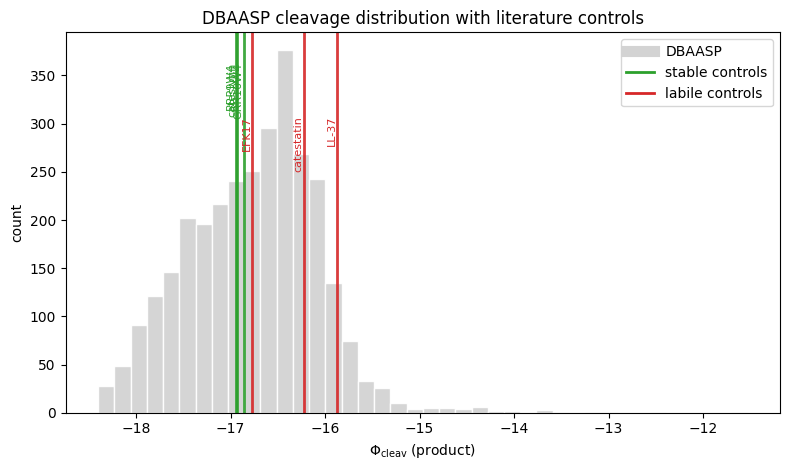

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(
    dbaasp["cleavage"],
    bins=40,
    color="lightgray",
    edgecolor="white",
    alpha=0.95,
    label="DBAASP",
)
colors = {"stable": "#2ca02c", "labile": "#d62728"}
for role, group in controls.groupby("role"):
    for _, row in group.iterrows():
        ax.axvline(
            row["cleavage"],
            color=colors[role],
            lw=2.0,
            alpha=0.9,
        )
        ax.text(
            row["cleavage"],
            ax.get_ylim()[1] * (0.92 if role == "stable" else 0.78),
            row["name"].split()[0],
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color=colors[role],
        )

# Legend proxies
from matplotlib.lines import Line2D

ax.legend(
    handles=[
        Line2D([0], [0], color="lightgray", lw=8, label="DBAASP"),
        Line2D([0], [0], color=colors["stable"], lw=2, label="stable controls"),
        Line2D([0], [0], color=colors["labile"], lw=2, label="labile controls"),
    ]
)
ax.set_xlabel(r"$\Phi_{\mathrm{cleav}}$ (product)")
ax.set_ylabel("count")
ax.set_title("DBAASP cleavage distribution with literature controls")
fig.tight_layout()
fig.savefig(OUT_DIR / "cleavage_controls_on_dbaasp.png", dpi=150)
plt.show()
